# HumMobCov — Main Analysis Notebook

Structured in three sections:
1. **INPUT** — choose the region, load the dataset, inspect configuration
2. **MAIN** — run the full processing pipeline (per-user metric computation)
3. **VISUALIZATION** — produce all plots from the saved per-user results

All paths, parameters and flags are controlled through:
- `src/constants.py` — global constants and directory layout
- `data/config/config_<REGION>.json` — feature flags (which metrics to compute)

---
## 0 · Imports

In [ ]:
import sys
from pathlib import Path

# Make the src package importable regardless of working directory
PROJECT_ROOT = Path().resolve().parent   # HumMobCov/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Central import hub — brings in numpy, pandas, skmob, matplotlib, etc.
# and all project classes / constants
from src import (
    # constants
    PROJECT_ROOT, DIR_SRC, DIR_OUTPUT, DIR_DATA, DIR_CONFIG,
    PERIOD_NAMES, PERIOD_DIVISION, PERIOD_NAMES_TO_DIVISION,
    MIN_POINTS_PER_USER, TIME_THRESHOLD_HOURS, US_BOUNDING_BOX,
    RURALITY_LEVELS, PARTY_NAMES, K_RADIUS_VALUES, LIST_REGIONS,
    # dataset classes
    DataSet_California, DataSet_Massachusets, dataset_info,
    # pipeline
    analyze_from_dataset, compute_all, get_config,
    # user
    User,
    # plotter
    plotter,
    # storage
    ParquetStore,
    # utilities
    get_already_saved_user_per_period, ifnotexistsmkdir,
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print('Project root:', PROJECT_ROOT)
print('Output dir:  ', DIR_OUTPUT)
print('Data dir:    ', DIR_DATA)


Project root: /home/aamaduzzi/HumMobCov
Output dir:   /home/aamaduzzi/HumMobCov/output
Data dir:     /home/aamaduzzi/HumMobCov/data


---
## 1 · INPUT

**Edit this section** to choose which region to analyse and to review / override any parameter.

In [2]:
# ─── Choose region ──────────────────────────────────────────────────────────
# Options: "CA"  (California)  or  "MA"  (Massachusetts)
REGION = "CA"

assert REGION in LIST_REGIONS, f"Unknown region '{REGION}'. Choose from {LIST_REGIONS}"

In [3]:
# ─── Optional parameter overrides ───────────────────────────────────────────
# Leave as None to use the defaults from constants.py

OVERRIDE_NP_            = None   # e.g. 30  (minimum stops per user per period)
OVERRIDE_T_THRESHOLD    = None   # e.g. 2   (minimum hours between stops)
OVERRIDE_OUTPUT_DIR     = None   # e.g. Path('/my/custom/output')
OVERRIDE_CONFIG_DIR     = None   # e.g. Path('/my/configs')

In [4]:
# ─── Initialise dataset ─────────────────────────────────────────────────────
if REGION == "CA":
    dataset = DataSet_California()
elif REGION == "MA":
    dataset = DataSet_Massachusets()

# Apply overrides
if OVERRIDE_NP_ is not None:
    dataset.np_ = OVERRIDE_NP_
if OVERRIDE_T_THRESHOLD is not None:
    dataset.t_threshold = OVERRIDE_T_THRESHOLD

print(f"Region:              {dataset.id_}")
print(f"Min points (np_):    {dataset.np_}")
print(f"Time threshold (h):  {dataset.t_threshold}")
print(f"Output directory:    {dataset.dir_output}")
print(f"Number of raw files: {len(dataset.dir_files)}")

Region:              CA
Min points (np_):    20
Time threshold (h):  1
Output directory:    /home/aamaduzzi/HumMobCov/milestones_analysis/CA/dataxuser
Number of raw files: 0


In [5]:
# ─── Preview algorithm-flow configuration ───────────────────────────────────
import json

cfg = get_config(REGION, config_dir=OVERRIDE_CONFIG_DIR)
print("Active feature flags:")
for key, val in cfg.items():
    if not key.startswith('_'):
        flag = '✓' if val else '✗'
        print(f"  {flag}  {key}")

Active feature flags:
  ✓  raw_trajectories
  ✓  is_radius_gyration
  ✗  already_computed_rg
  ✓  is_weekly_radius_gyration
  ✓  is_gonzalez
  ✗  already_computed_gonzalez
  ✓  is_random_entropy
  ✗  already_computed_random_entropy
  ✓  is_uncorrelated_entropy
  ✗  already_computed_uncorrelated_entropy
  ✓  is_real_entropy
  ✗  already_computed_real_entropy
  ✓  is_distance
  ✗  already_computed_distance
  ✓  is_home
  ✗  already_computed_home
  ✓  is_krg
  ✗  already_computed_krg
  ✓  is_St
  ✗  already_computed_St
  ✓  is_fraction_time
  ✗  already_computed_fraction_time
  ✓  is_county_rural
  ✗  already_computed_county_rural
  ✓  is_frequency
  ✗  already_computed_frequency
  ✗  is_week2points
  ✓  save_results


In [ ]:
# ─── Preview time periods ────────────────────────────────────────────────────
print("Analysis periods:")
for name, (start, end) in PERIOD_NAMES_TO_DIVISION.items():
    print(f"  {name:25s}  {start.date()}  →  {end.date()}")

Analysis periods:
  15 jan - 15 march          2020-01-15  →  2020-03-15
  15 march - 15 may          2020-03-15  →  2020-05-15
  15 may - sept              2020-05-15  →  2020-09-30


: 

---
## 2 · MAIN

Runs the full per-user computation pipeline **when raw parquet files are available**
(i.e. `raw_trajectories: true` in the config and the raw data is accessible).

**If only pre-computed features are available** (the usual case in this environment),
the pipeline is skipped automatically and the summary cell below reads user counts
directly from the existing files in `dataxuser/`.

To populate `dataxuser/` from the legacy shard files in `milestones_analysis/`,
run the extraction helper once:

```python
from src.utils import extract_dataxuser_from_shards
extract_dataxuser_from_shards(REGION, np_=dataset.np_, t=dataset.t_threshold)
```


In [ ]:
# ─── Initialise parquet store ────────────────────────────────────────────────
# The store lives next to dataxuser/ inside the region's milestone directory.
from src.constants import DIR_MILESTONES_SERVER

store = ParquetStore(
    base_dir     = DIR_MILESTONES_SERVER / REGION,
    np_          = dataset.np_,
    t_threshold  = dataset.t_threshold,
)

# ─── Decide: run from raw trajectories, or load from existing data? ───────────
#
#  CASE A — raw parquet files are available (cfg["raw_trajectories"] = true):
#     compute all metrics, save results to the parquet store.
#     Already-computed users are skipped automatically (resume logic).
#
#  CASE B — raw files unavailable; legacy dataxuser/ CSV.gz files exist:
#     migrate them into the parquet store ONCE (idempotent, resume-safe).
#
#  CASE C — raw files unavailable AND parquet store already populated:
#     nothing to do, skip straight to visualisation.

legacy_dir = DIR_MILESTONES_SERVER / REGION / "dataxuser"

if cfg.get("raw_trajectories") and len(dataset.dir_files) > 0:
    # ── CASE A: full computation from raw data ────────────────────────────
    print("Running full computation pipeline (raw trajectories available)…")
    analyze_from_dataset(
        dataset,
        region     = REGION,
        config_dir = OVERRIDE_CONFIG_DIR,
        output_dir = OVERRIDE_OUTPUT_DIR,
        store      = store,
        batch_size = 500,            # users accumulated before each shard write
    )
    print("Computation complete. Consolidating shards…")
    for p in dataset.period_names:
        store.consolidate_all(p)
    print("Done.")

else:
    # ── CASE B / C: decide whether to migrate legacy files ────────────────
    needs_migration = any(
        len(store.get_computed_users(p, "all_scalars")) == 0
        for p in PERIOD_NAMES
    )
    if needs_migration and legacy_dir.exists():
        print(
            "Raw trajectories not available. "
            "Migrating legacy per-user CSV.gz files to the parquet store…\n"
            "(Already-migrated users will be skipped — safe to re-run.)"
        )
        store.migrate_all_periods(
            legacy_dir   = legacy_dir,
            period_names = PERIOD_NAMES,
            np_          = dataset.np_,
            t            = dataset.t_threshold,
            batch_size   = 500,
            consolidate  = True,   # merge shards after each period
        )
    else:
        print(
            "Parquet store already populated (or no legacy files found). "
            "Skipping migration — proceeding to visualisation."
        )


Raw trajectories not available (raw_trajectories=True, raw files found=0).
Extracting per-user files from pre-computed shard directories...
  [CA] Extracting period: '15 jan - 15 march' ...


    → 1438004 users written (all_scalars).
    → 73 users written (gonzalez).
  [CA] Extracting period: '15 march - 15 may' ...


In [ ]:
# ─── Pipeline summary ────────────────────────────────────────────────────────
# Show how many users are available per period and metric kind.
# Reads only parquet footer metadata (no data loaded).

print("Users available in parquet store:")
for period in PERIOD_NAMES:
    scalars = store.get_computed_users(period, "all_scalars")
    gonzalez = store.get_computed_users_long(period, "gonzalez")
    st = store.get_computed_users(period, "S")
    wrg = store.get_computed_users(period, "weekly_rg")
    freq = store.get_computed_users_long(period, "frequency")
    print(
        f"  {period:25s}  "
        f"scalars={len(scalars):>7,}  "
        f"gonzalez={len(gonzalez):>7,}  "
        f"S(t)={len(st):>7,}  "
        f"weekly_rg={len(wrg):>7,}  "
        f"freq={len(freq):>7,}"
    )


Users available per period (from pre-computed files):
  15 jan - 15 march                 0 users   [pre-computed files]
    ↳ dataxuser dir: /home/aamaduzzi/HumMobCov/milestones_analysis/CA/dataxuser
  15 march - 15 may                 0 users   [pre-computed files]
    ↳ dataxuser dir: /home/aamaduzzi/HumMobCov/milestones_analysis/CA/dataxuser
  15 may - sept                     0 users   [pre-computed files]
    ↳ dataxuser dir: /home/aamaduzzi/HumMobCov/milestones_analysis/CA/dataxuser


---
## 3 · VISUALIZATION

All plots are produced from the already-saved per-user files.
Run this section independently of Section 2 once results are on disk.

In [ ]:
# ─── Initialise plotter ──────────────────────────────────────────────────────
# Pass `store=store` to use the fast parquet backend.
# Omit it (or pass None) to fall back to the legacy per-file mode.

plt_obj = plotter(
    np_            = dataset.np_,
    period_division= dataset.period_division,
    period_names   = dataset.period_names,
    t_threshold    = dataset.t_threshold,
    region         = REGION,
    county2party   = dataset.county2party,
    df_rurality    = dataset.df_rurality,
    output_dir     = OVERRIDE_OUTPUT_DIR,
    store          = store,          # ← parquet-store mode
)

# Show user counts per period (from parquet store metadata)
print("Users available per period (from parquet store):")
for period in plt_obj.period_names:
    n = len(store.get_computed_users(period, "all_scalars"))
    print(f"  {period:25s}  {n:>8,} users")


  15 jan - 15 march          {'all_scalars': 0, 'gonzalez': 0, 'S': 0, 'frequency': 0, 'weekly_rg': 0}
  15 march - 15 may          {'all_scalars': 0, 'gonzalez': 0, 'S': 0, 'frequency': 0, 'weekly_rg': 0}
  15 may - sept              {'all_scalars': 0, 'gonzalez': 0, 'S': 0, 'frequency': 0, 'weekly_rg': 0}


### 3.1 Radius of Gyration

Scalar file index built in 0.0s


ZeroDivisionError: 0.0 cannot be raised to a negative power

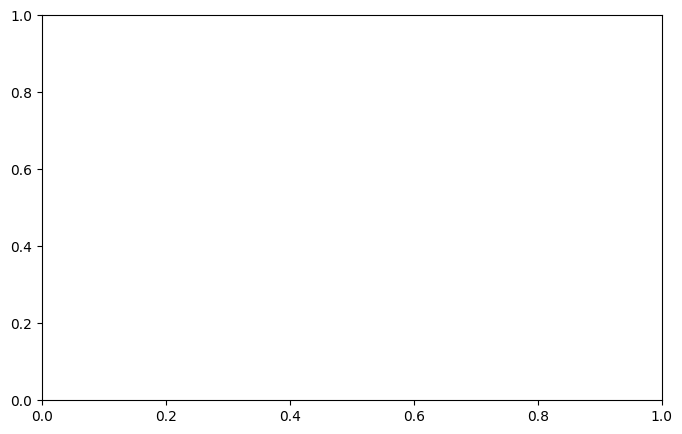

In [ ]:
plt_obj.plot_rg()

In [ ]:
plt_obj.plot_rg_party_per_period()

In [ ]:
plt_obj.plot_rg_rurality_per_period()

### 3.2 Weekly Radius of Gyration

In [ ]:
plt_obj.plot_weekly_rg()

In [ ]:
plt_obj.plot_rg_rurality_weekly()

In [ ]:
plt_obj.plot_rg_party_weekly()

### 3.3 k-Radius of Gyration

In [ ]:
plt_obj.plot_krg()

### 3.4 Distance

In [ ]:
plt_obj.plot_distance()

### 3.5 Entropy

In [ ]:
plt_obj.plot_entropy()

### 3.6 Exploration Curve S(t)

In [ ]:
plt_obj.plot_St()

### 3.7 Location Frequency

In [ ]:
plt_obj.plot_frequency()

### 3.8 Gonzalez Trajectory Shape

In [ ]:
plt_obj.plot_gonzalez()

In [ ]:
plt_obj.plot_sigmaxy()